In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
%matplotlib widget

Gaussian Beam helper functions

In [76]:
# Waist
def w_z(w0, z, zR):
    return w0 * np.sqrt(1 + (z / zR) ** 2)

# Rayleigh Range
def R(z, z_r):
    return z * (1 + (z_r / z) ** 2)

# Q matrix
def q_inv(z, z_r, w0, wl):
    if np.abs(z) < 1e-10:
        return - 1 / (1j * (np.pi * w0 ** 2) / (wl))
    else:
        return 1 / R(z, z_r) - 1j * wl / (np.pi * w_z(w0, z, z_r) ** 2)

def qinv_ABCD(q_inv, A, B, C, D):
    return (C + D * q_inv) / (A + B * q_inv)

#Matrix version
def Qinv_ABCD(Qinv, A, B, C, D):
    return (C + D @ Qinv) * np.linalg.inv(A + B @ Qinv)
    
# Rayleigh distance
def zR(w0, wavelength):
    return (np.pi * w0 ** 2) / wavelength

def gaussian_beam(x, y, qinv, k):
    return np.exp(1j * k * (x ** 2 + y ** 2) / 2 * qinv)

# def misaligned_gaussian()

In [77]:
def vector_dot_matrix(a, M, b):
    # a & b should be column vectors of size P x Q, and M a P x P matrix. 
    # The output will be a vector of scalars of size Q. 
    # Note that the operation of <a|M|b> or a.M.b is not equivalent to np.dot(a.T, np.dot(M, b)), 
    # but rather to np.sum(a * np.dot(M, b), axis=0) or 
    # or np.vecdot(a.T, (M @ b).T) or
    # np.einsum('ij,ij->j', a, np.dot(M, b)) or 
    # np.einsum('ij,ik,kj->j', a, M, b).

    #As a brief example if:
    # M = np.array([[1, 2],
    #             [3, 4]])

    # a = np.array([[1, 2],
    #             [3, 4]])

    # b = np.array([[5, 6],
    #             [7, 8]])

    # The wrong method will return:

    # dot_wrong = np.dot(a.T, np.dot(M, b))
    # print("Dot All (a.T @ M @ b):\n", dot_wrong)
    # # Output:
    # # [[1*19 + 3*43, 1*22 + 3*50],
    # #  [2*19 + 4*43, 2*22 + 4*50]]

    # Where as the right method will return:
    # dot_right = np.sum(a * np.dot(M, b), axis=0)
    # print("Dot right (sum(a * (M @ b))):\n", dot_right)
    # # Output:
    # # [1*19 + 3*43, 2*22 + 4*50]

    #Both method will give differing outputs:
    # dot_wrong computes a matrix where each element (i, j) is the dot product of a[:, i] with M @ b[:, j].
    # dot_right computes a vector where each element j is the dot product of a[:, j] with M @ b[:, j].

    return np.sum(a * (M @ b), axis=0)#np.vecdot(a.T, (M @ b).T)

def vector_dot_matrix_3D(a, M, b):
    # If M has a leading dimension, then this is the only way I can figure out for now how to 
    # do the vector dot product. There must be a better way to do this, but for now it works.
    return np.einsum('ijk,ik->i', Q, a*b)

def zero_phase(u, idx_x, idx_y):
    u_centre = u[idx_x, idx_y]
    phase_difference = 0 - np.angle(u_centre)
    u *= np.exp(1j * phase_difference)
    return u

def zero_phase_1D(u, idx_x):
    u_centre = u[idx_x]
    phase_difference = 0 - np.angle(u_centre)
    u *= np.exp(1j * phase_difference)
    return u

Collins integral solutions

In [78]:
# # Very hard to get this working for some reason, scaling the input or output with A seems to be the issue,
# # but I will leave it for now, and use normal fresnel propagation instead
# def collins_FFT(U_in, pixel_size, lam, A, B, C, D, L0):
#     """
#     Propagate an input field U_in(xi, eta) through an ABCD system.
    
#     Parameters:
#     -----------
#     U_in   : 2D array, complex
#         Input field sampled on (xi, eta) grid.
#     r2 : float
#         Sampling intervals in the output plane.
#     lam    : float
#         Wavelength.
#     A, B, C, D : floats
#         ABCD matrix elements.
#     a*L0   : float, optional
#         Additional phase factor e^{i k L_0} if desired.
    
#     Returns:
#     --------
#     U_out  : 2D array, complex
#         Output field on the (x, y) grid.  The (x, y) points are understood
#         to be x = A * xi, y = A * eta in this scheme.
#     """

#     # 1) Setup sampling
#     Ny, Nx = U_in.shape
#     x_o = r2[1, :].reshape(Ny, Nx)
#     y_o = r2[0, :].reshape(Ny, Nx)

#     dx = (x_o[0, 1] - x_o[0, 0])
#     dy = (y_o[1, 0] - y_o[0, 0])

#     fy_vals = np.fft.fftfreq(Nx, d=dx)  # or arrange in [-fxmax..fxmax]
#     fx_vals = np.fft.fftfreq(Ny, d=dy)
#     FY, FX = np.meshgrid(fy_vals, fx_vals)

#     # 3) Fourier transform of input field
#     U1_F = np.fft.fft2(U_in)
#     T = np.exp(-1j * np.pi * (lam * B / A) * (FX**2 + FY**2))
#     U2_IF = np.fft.ifft2(U1_F * T)

#     phase_C = np.exp(1j * np.pi * (C/(lam*A)) * (x_o**2 + y_o**2))

#     U_out = np.exp(-1j * k * L0)/A * phase_C * U2_IF

#     return U_out


def evaluate_on_scaled_grid(U0, x, y, A, method='linear', fill_value=0):
    """
    Evaluate U0 on a grid scaled by A: sample U0 at (x/A, y/A).

    Parameters
    ----------
    U0 : 2D ndarray, shape (Ny, Nx)
        Input field on grid defined by x and y.
    x : 1D ndarray of length Nx
        Coordinates along x (must be monotonic).
    y : 1D ndarray of length Ny
        Coordinates along y (must be monotonic).
    A : float
        Scaling factor; you’ll get U0(x/A, y/A).
    method : {'linear','nearest'}, optional
        Interpolation method.
    fill_value : float, optional
        Value for points outside the original grid.

    Returns
    -------
    U0_scaled : 2D ndarray, shape (Ny, Nx)
        U0 evaluated at the scaled grid.
    """
    # Build interpolator on the original grid (note ordering: (y,x))
    interp = RegularGridInterpolator(
        (x, y), U0,
        method=method,
        bounds_error=False,
        fill_value=fill_value
    )

    # New sample points: (X_new[i,j], Y_new[i,j]) = ( x[j]/A, y[i]/A )
    X_new, Y_new = np.meshgrid(x/A, y/A, indexing='xy')

    # Flatten to a list of points for the interpolator
    pts = np.stack([X_new.ravel(), Y_new.ravel()], axis=-1)  # (Ny*Nx, 2)

    # Interpolate and reshape
    U0_scaled = interp(pts).reshape(U0.shape)
    return U0_scaled



def collins_dfft(U0, A, B, C, wavelength, dx):

    N, M = U0.shape
    L0 = N * dx

    coords = np.arange(N, dtype=float) * dx
    X, Y = np.meshgrid(coords, coords, indexing='ij')

    # u0_scaled = evaluate_on_scaled_grid(U0, coords, coords, A, method='linear', fill_value=0)
    
    # Phase term to be applied to the output field
    phase_out = np.exp(1j * (np.pi / wavelength) * (C / A) * (X**2 + Y**2))

    fx = np.fft.fftfreq(N, dx / A)
    fy = np.fft.fftfreq(M, dx / A)
    Fx, Fy = np.meshgrid(fx, fy)

    H = np.exp(-1j * np.pi * wavelength * (B / A) * (Fx**2 + Fy**2))

    U0fft = np.fft.fft2(U0)
    G = H * U0fft
    U1_ifft = np.fft.ifft2(G)

    Uout = (1 / A) * phase_out * U1_ifft

    return Uout


def FresnelPropagator(u1, L, wavelength, z):
    
    M, N = u1.shape
    dx = L / M

    fx = np.fft.fftfreq(N, dx)
    fy = np.fft.fftfreq(M, dx)
    FX, FY = np.meshgrid(fx, fy)

    H = np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))

    U1 = np.fft.fft2(u1)
    U2 = H * U1
    u2 = np.fft.ifft2(U2)
    
    return u2

def fresnel_solution(E0, Y, X, ps, lambda0, z1, f, z2):
    k = 2 * np.pi / lambda0
    L = E0.shape[0] * ps
    E_lens = FresnelPropagator(E0, L, lambda0, z1).copy()
    E_lens *= np.exp((-1j * k) / (2 * f) * (X ** 2 + Y ** 2)).copy()
    E_final = FresnelPropagator(E_lens, L, lambda0, z2)

    return E_final

def collins_analytic(Q1_inv, A, B, C, D, r2, r1m, theta1m, k, L0):
    """
    Compute the misaligned Collins integral analytically.

    Parameters:
    -----------
    Q1_inv : complex or ndarray, shape (2,2)
        Inverse of the complex beam parameter at the source plane.
    A, B, C, D : ndarray, shape (2,2)
        Elements of the ABCD ray-transfer matrix.
    r2 : ndarray, shape (2, Ny, Nx)
        Coordinates at the observation plane;
        r2[0,:,:] = y₂ grid, r2[1,:,:] = x₂ grid.
    r1m : ndarray, shape (2, Nm)
        Nominal source-plane coordinate vector(s), e.g. [[x₁],[y₁]].
    theta1m : ndarray, shape (2, Nm)
        Misalignment tilt angles at the source plane, same layout as r1m.
    k : float
        Wave number (2π/λ).
    L0 : float
        Propagation distance for extra phase term exp(-i k L0).

    Returns:
    --------
    E2 : ndarray, shape (Ny, Nx)
        Complex field at the observation plane.
    """
    B_inv = np.linalg.inv(B)


    # displaced source plane coordinate
    r2m = A @ r1m + B @ theta1m
    Q1 = np.linalg.inv(Q1_inv)

    # inverse Q at output plane
    Q2_inv = Qinv_ABCD(Q1_inv, A, B, C, D)
    constant_phase = np.exp(-1j * k * L0)
    amplitude = 1 / np.sqrt(np.linalg.det(A + B @ Q1_inv))

    # misalignment phases
    mis_r1 = (vector_dot_matrix(r1m, A @ B_inv, r1m)
              - 2 * vector_dot_matrix(r1m, B_inv, r2))
    mis_r2 = (vector_dot_matrix(r2m,
                Q1 @ np.linalg.inv(B @ (A @ Q1 + B)),
                r2m)
              - 2 * vector_dot_matrix(r2m,
                Q1 @ np.linalg.inv(B @ (A @ Q1 + B)),
                r2))

    Q2_term = vector_dot_matrix(r2, Q2_inv, r2)

    return amplitude * constant_phase * np.exp(1j * k/2 * (Q2_term + mis_r1 - mis_r2))


def collins_ashcraft(Q1_inv, A, B, C, D, r2, r1m, k, L0):
    """
    Compute the misaligned Collins integral analytically.

    Parameters:
        Q1_inv : complex
            Inverse of the Q parameter at the source plane.
        A, B, C, D : complex
            Components of the ABCD matrix.
        r2 : 3D array
            Coordinates at the observation plane.
        r1m : 3D array
            Coordinates at the source plane.
        k : float
            Wave number.
        L0 : float
            Propagation distance.

    Returns:
        E2 : 2D array
            The field at the observation plane.
    """
    # Compute the ABCD matrix at the observation plane
    try:
        B_inv = np.linalg.inv(B)
    except np.linalg.LinAlgError:
        B_inv = np.eye(B.shape[0])
    
    Q2_inv = Qinv_ABCD(Q1_inv, A, B, C, D)
    constant_phase = np.exp(-1j * k * L0)
    amplitude = 1 / np.sqrt(np.linalg.det(A + B @ Q1_inv))

    misaligned_phase_r1 = (vector_dot_matrix(r1m, A @ B_inv, r1m) - 2 * vector_dot_matrix(r1m, B_inv, r2))
    Q2_term = vector_dot_matrix(r2, Q2_inv, r2)
    
    return amplitude * constant_phase * np.exp(1j * k / 2 * (Q2_term + misaligned_phase_r1))

Setup Parameters

In [79]:
#setup params
pixel_size = 5e-6
wavelength = 1e-4
wo = 0.5e-3
k = 2 * np.pi / wavelength

In [80]:
# Code for well defined lens matrix setup for early testing

dist_to_lens = z1 = 0
f = 5e-3
z2 = (1 / f)**-1 + 2e-3
dist_to_after = z2
L0 = dist_to_after + dist_to_lens

free_space_mat = np.array([[1, dist_to_lens], [0, 1]])
lens_mat = np.array([[1, 0], [-1/f, 1]])
free_space_mat2 = np.array([[1, dist_to_after], [0, 1]])

A = np.zeros((4, 4))
B = np.zeros((4, 4))
C = np.zeros((4, 4))
D = np.zeros((4, 4))

A[:2, :2] = np.eye(2)
B[:2, 2:] = np.eye(2)
C[2:, :2] = np.eye(2)
D[2:, 2:] = np.eye(2)

free_space_mat = A + (B * dist_to_lens) + D
lens_mat = A + (C * -1 / f) + D
free_space_mat2 = A + (B * dist_to_after) + D
ABCD = free_space_mat2 @ lens_mat @ free_space_mat

print(f"ABCD: \n{ABCD}")
A, B, C, D = ABCD[0:2, 0:2], ABCD[0:2, 2::], ABCD[2::, 0:2], ABCD[2::, 2::]
a, b, c, d = ABCD[0, 0], ABCD[0, 2], ABCD[2, 0], ABCD[2, 2]

print(f"a: {a}, b: {b}, c: {c}, d: {d}")

ABCD: 
[[-4.e-01  0.e+00  7.e-03  0.e+00]
 [ 0.e+00 -4.e-01  0.e+00  7.e-03]
 [-2.e+02  0.e+00  1.e+00  0.e+00]
 [ 0.e+00 -2.e+02  0.e+00  1.e+00]]
a: -0.4, b: 0.007, c: -200.0, d: 1.0


In [81]:
# Calculate offset
y0, x0 = 0.001, 0

# degrees offset
theta_y, theta_x = np.random.uniform(0, 0, 2)

rad_yx = np.deg2rad((theta_y, theta_x))

tan_theta_x = np.tan(rad_yx[1])
tan_theta_y = np.tan(rad_yx[0])

r1m = np.array([[y0, x0]]).T
theta1m = np.array([[tan_theta_y, tan_theta_x]]).T

# These coordinates are neccessary for Diffractio angle tilts, but we don't need this for now.
# theta = np.arctan(np.sqrt(tan_theta_x**2 + tan_theta_y**2))
# phi = np.arctan2(tan_theta_y, tan_theta_x)

In [82]:
#Detector coordinates
shape = (2048, 2048)
det_size_y = shape[0] * pixel_size
det_size_x = shape[1] * pixel_size

x_range = (-det_size_x / 2, det_size_x / 2)
y_range = (-det_size_y / 2, det_size_y / 2)

x_det = np.linspace(-det_size_x / 2, det_size_x / 2, shape[0])
y_det = np.linspace(-det_size_y / 2, det_size_y / 2, shape[1])

Y, X = np.meshgrid(y_det, x_det, indexing="ij")

#Set detector coordinates at source and observation planes to be the same
r1 = r2 = np.stack([Y.ravel(), X.ravel()], axis=0)

In [83]:
q1_inv = q_inv(1e-13, zR(wo, wavelength), wo, wavelength)
Q1_inv = np.eye(2) * q1_inv
gaussian_shifted_fresnel = gaussian_beam((Y - y0), (X - x0), q1_inv, k).ravel()
gaussian_shifted_collins = gaussian_beam((Y - y0) / A[0, 0], (X - x0) / A[0, 0], q1_inv, k).ravel()
tilted_shifted_plane_wave = np.exp(-1j * k * ((r1 - r1m)).T @ theta1m)[:, 0]

gaussian_misaligned_fresnel = (gaussian_shifted_fresnel * tilted_shifted_plane_wave).reshape(shape[0], shape[1])
gaussian_misaligned_collins = (gaussian_shifted_collins * tilted_shifted_plane_wave).reshape(shape[0], shape[1])

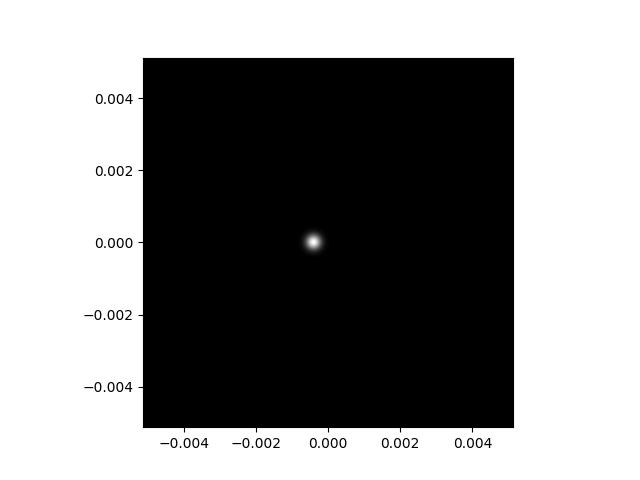

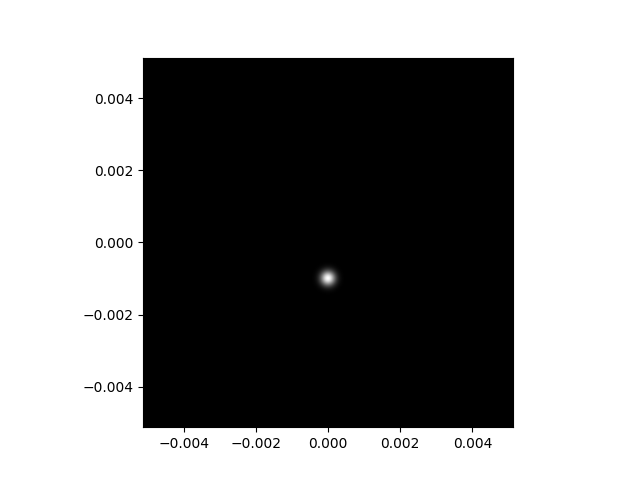

In [84]:
gaussian_misaligned_collins_scaled = evaluate_on_scaled_grid(gaussian_misaligned_fresnel, x_det, y_det, A[0, 0], method='linear', fill_value=0)

plt.figure()
plt.imshow(np.abs(gaussian_misaligned_collins_scaled), cmap='gray', extent=(x_det[0], x_det[-1], y_det[0], y_det[-1]))
plt.figure()
plt.imshow(np.abs(gaussian_misaligned_collins), cmap='gray', extent=(x_det[0], x_det[-1], y_det[0], y_det[-1]))

In [85]:
gaussian_collins_FFT = collins_dfft(gaussian_misaligned_collins, A[0,0], B[0,0], C[0,0], wavelength, pixel_size)
gaussian_fresnel_FFT = fresnel_solution(gaussian_misaligned_fresnel, Y, X, pixel_size, wavelength, z1, f, z2)
gaussian_collins_FFT = zero_phase(gaussian_collins_FFT, shape[0]//2, shape[1]//2)
gaussian_fresnel_FFT = zero_phase(gaussian_fresnel_FFT, shape[0]//2, shape[1]//2)

In [86]:
gaussian_analytic = collins_analytic(Q1_inv, A, B, C, D, r2, r1m, theta1m, k, L0)
gaussian_analytic = gaussian_analytic.reshape(shape)
gaussian_analytic = zero_phase(gaussian_analytic, shape[0]//2, shape[1]//2)

In [87]:
r2m = A @ r1m + B @ theta1m
print(f"r2m: {r2m}")
gaussian_ashcraft = collins_ashcraft(Q1_inv, A, B, C, D, r2, r1m, k, L0)
gaussian_ashcraft = gaussian_ashcraft.reshape(shape)
gaussian_ashcraft = zero_phase(gaussian_ashcraft, shape[0]//2, shape[1]//2)

r2m: [[-0.0004]
 [ 0.    ]]


In [88]:
mid_index = shape[0]//2

gaussian_fresnel_FFT_mag_1D = np.abs(gaussian_fresnel_FFT[:, mid_index])
gaussian_fresnel_FFT_phase_1D = np.angle(gaussian_fresnel_FFT[:, mid_index])

gaussian_collins_FFT_mag_1D = np.abs(gaussian_collins_FFT[:, mid_index])
gaussian_collins_FFT_phase_1D = np.angle(gaussian_collins_FFT[:, mid_index])

gaussian_analytic_mag_1D = np.abs(gaussian_analytic[:, mid_index])
gaussian_analytic_phase_1D = np.angle(gaussian_analytic[:, mid_index])

gaussian_ashcraft_mag_1D = np.abs(gaussian_ashcraft[:, mid_index])
gaussian_ashcraft_phase_1D = np.angle(gaussian_ashcraft[:, mid_index])


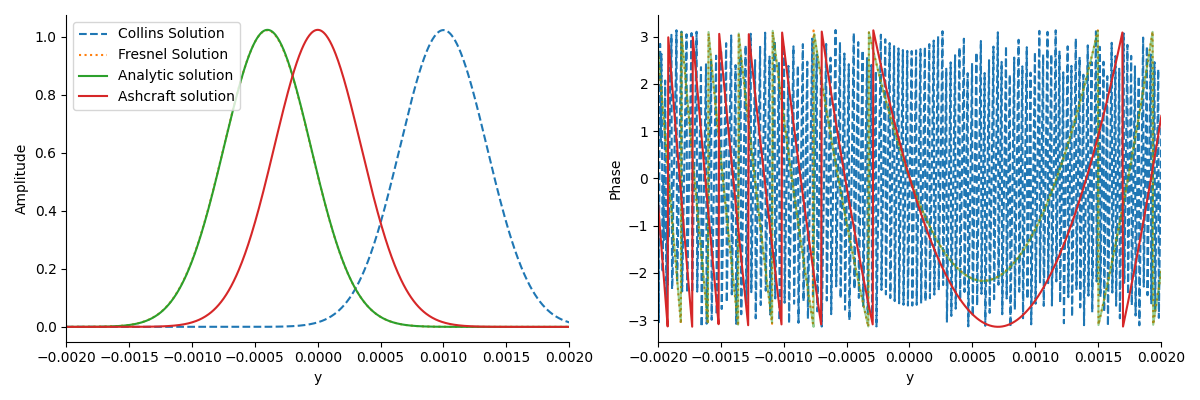

In [89]:
# Create a 1x2 subplot grid for the cross-sections
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Cross-section of Magnitude
axes[0].plot(x_det, gaussian_collins_FFT_mag_1D, label='Collins Solution', linestyle='--')
axes[0].plot(x_det, gaussian_fresnel_FFT_mag_1D, label='Fresnel Solution', linestyle=':')
axes[0].plot(x_det, gaussian_analytic_mag_1D, label='Analytic solution')
axes[0].plot(x_det, gaussian_ashcraft_mag_1D, label='Ashcraft solution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Amplitude')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend()

# Right plot: Cross-section of Phase
axes[1].plot(x_det, gaussian_collins_FFT_phase_1D, label='Collins Solution', linestyle='--')
axes[1].plot(x_det, gaussian_fresnel_FFT_phase_1D, label='Fresnel Solution', linestyle=':')
axes[1].plot(x_det, gaussian_analytic_phase_1D, label='Analytic solution', alpha = 0.5)
axes[1].plot(x_det, gaussian_ashcraft_phase_1D, label='Ashcraft solution')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Phase')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[0].set_xlim(-2e-3, 2e-3)
axes[1].set_xlim(-2e-3, 2e-3)
plt.tight_layout()
plt.show()


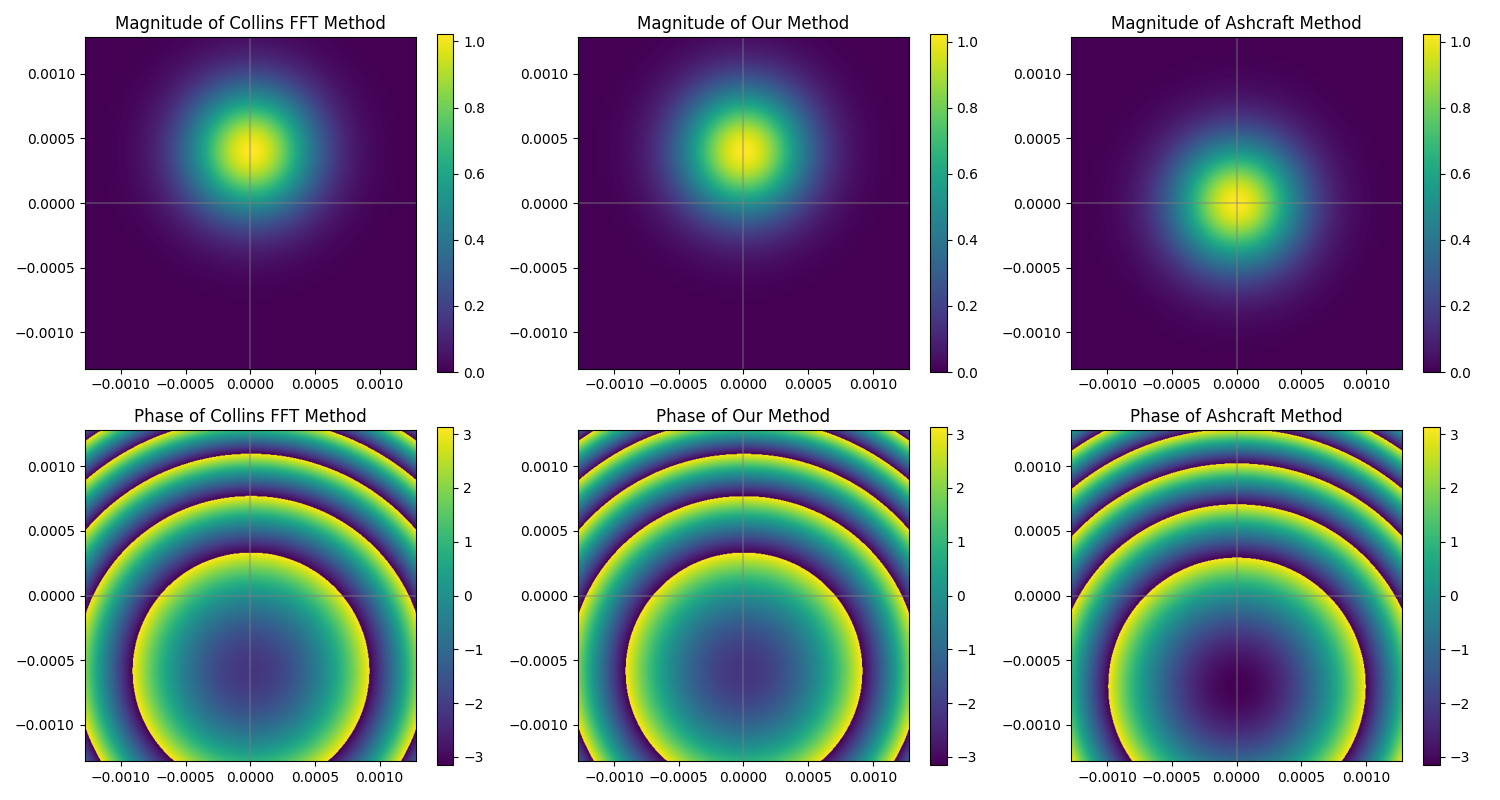

In [90]:
# Create a 2x3 subplot grid for the images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top-left: Magnitude of gaussian_FFT
im = axes[0, 0].imshow(np.abs(gaussian_fresnel_FFT), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[0, 0].set_xlim(x_range[0]/4, x_range[1]/4)
axes[0, 0].set_ylim(y_range[0]/4, y_range[1]/4)
axes[0, 0].set_title('Magnitude of Collins FFT Method')
fig.colorbar(im, ax=axes[0, 0])

# Top-middle: Magnitude of gaussian_analytic
im = axes[0, 1].imshow(np.abs(gaussian_analytic), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[0, 1].set_title('Magnitude of Our Method')
axes[0, 1].set_xlim(x_range[0]/4, x_range[1]/4)
axes[0, 1].set_ylim(y_range[0]/4, y_range[1]/4)
fig.colorbar(im, ax=axes[0, 1])

# Top-right: Magnitude of Ashcraft Method
im = axes[0, 2].imshow(np.abs(gaussian_ashcraft), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[0, 2].set_title('Magnitude of Ashcraft Method')
axes[0, 2].set_xlim(x_range[0]/4, x_range[1]/4)
axes[0, 2].set_ylim(y_range[0]/4, y_range[1]/4)
fig.colorbar(im, ax=axes[0, 2])

# Bottom-left: Phase of gaussian_FFT
im = axes[1, 0].imshow(np.angle(gaussian_fresnel_FFT), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[1, 0].set_title('Phase of Collins FFT Method')
axes[1, 0].set_xlim(x_range[0]/4, x_range[1]/4)
axes[1, 0].set_ylim(y_range[0]/4, y_range[1]/4)
fig.colorbar(im, ax=axes[1, 0])

# Bottom-middle: Phase of gaussian_analytic
im = axes[1, 1].imshow(np.angle(gaussian_analytic), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[1, 1].set_xlim(x_range[0]/4, x_range[1]/4)
axes[1, 1].set_ylim(y_range[0]/4, y_range[1]/4)
axes[1, 1].set_title('Phase of Our Method')
fig.colorbar(im, ax=axes[1, 1])

# Bottom-right: Phase of Ashcraft Method
im = axes[1, 2].imshow(np.angle(gaussian_ashcraft), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[1, 2].set_xlim(x_range[0]/4, x_range[1]/4)
axes[1, 2].set_ylim(y_range[0]/4, y_range[1]/4)
axes[1, 2].set_title('Phase of Ashcraft Method')
fig.colorbar(im, ax=axes[1, 2])

# Add center lines on each subplot
for row in axes:
    for ax in row:
        ax.axhline(y=0, color='gray', alpha=0.4)
        ax.axvline(x=0, color='gray', alpha=0.4)

plt.tight_layout()
plt.show()

Two Beam inteference after lens

[[0.]
 [0.]]


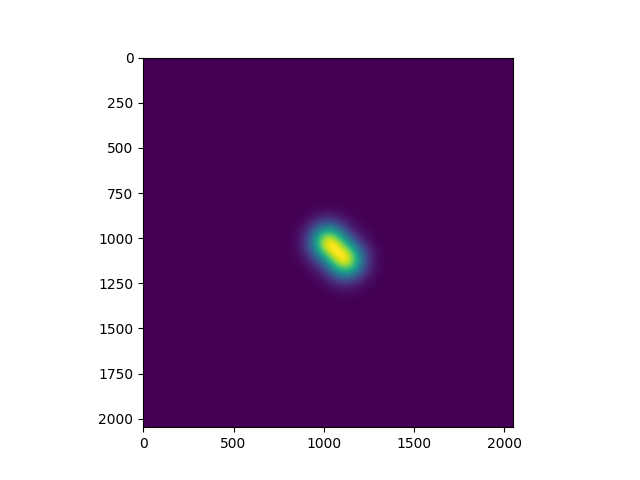

In [91]:
q1_inv = q_inv(1e-13, zR(wo, wavelength), wo, wavelength)
Q1_inv = np.eye(2) * q1_inv

x01 = 0
y01 = 0
x02 = 0.5e-3
y02 = 0.5e-3

r1m1 = np.array([[y01, x01]]).T
r1m2 = np.array([[y02, x02]]).T

print(theta1m)

gaussian_shifted_1 = gaussian_beam((Y - y01), (X - x01), q1_inv, k).ravel()
gaussian_shifted_2 = gaussian_beam((Y - y02), (X - x02), q1_inv, k).ravel()

tilted_shifted_plane_wave1 = np.exp(-1j * k * ((r1 - r1m1)).T @ theta1m)[:, 0]
tilted_shifted_plane_wave2 = np.exp(-1j * k * ((r1 - r1m2)).T @ theta1m)[:, 0]

gaussian_misaligned1 = (gaussian_shifted_1 * tilted_shifted_plane_wave1).reshape(shape[0], shape[1])
gaussian_misaligned2 = (gaussian_shifted_2 * tilted_shifted_plane_wave2).reshape(shape[0], shape[1])

gaussian_misaligned = gaussian_misaligned1 + gaussian_misaligned2

plt.figure()
plt.imshow(np.abs(gaussian_misaligned))

In [92]:
gaussian_FFT = fresnel_solution(gaussian_misaligned, Y, X, pixel_size, wavelength, z1, f, z2)
gaussian_FFT = zero_phase(gaussian_FFT, shape[0]//2, shape[1]//2)

In [93]:
gaussian_analytic1 = collins_analytic(Q1_inv, A, B, C, D, r2, r1m1, theta1m, k, L0)
gaussian_analytic2 = collins_analytic(Q1_inv, A, B, C, D, r2, r1m2, theta1m, k, L0)
gaussian_analytic = gaussian_analytic1 + gaussian_analytic2
gaussian_analytic = gaussian_analytic.reshape(shape)
gaussian_analytic = zero_phase(gaussian_analytic, shape[0]//2, shape[1]//2)

In [94]:
mid_index = shape[0]//2

gaussian_FFT_mag_1D = np.abs(gaussian_FFT[:, mid_index])
gaussian_FFT_phase_1D = np.angle(gaussian_FFT[:, mid_index])

gaussian_analytic_mag_1D = np.abs(gaussian_analytic[:, mid_index])
gaussian_analytic_phase_1D = np.angle(gaussian_analytic[:, mid_index])

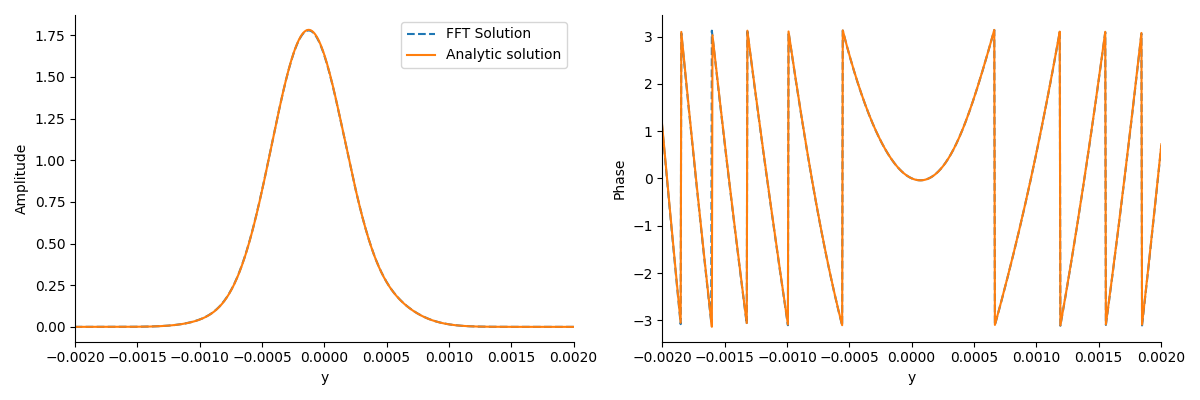

In [95]:
# Create a 1x2 subplot grid for the cross-sections
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Cross-section of Magnitude
axes[0].plot(x_det, gaussian_FFT_mag_1D, label='FFT Solution', linestyle='--')
axes[0].plot(x_det, gaussian_analytic_mag_1D, label='Analytic solution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Amplitude')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend()

# Right plot: Cross-section of Phase
axes[1].plot(x_det, gaussian_FFT_phase_1D, label='FFT Solution', linestyle='--')
axes[1].plot(x_det, gaussian_analytic_phase_1D, label='Analytic solution')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Phase')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[0].set_xlim(-2e-3, 2e-3)
axes[1].set_xlim(-2e-3, 2e-3)
plt.tight_layout()
plt.show()

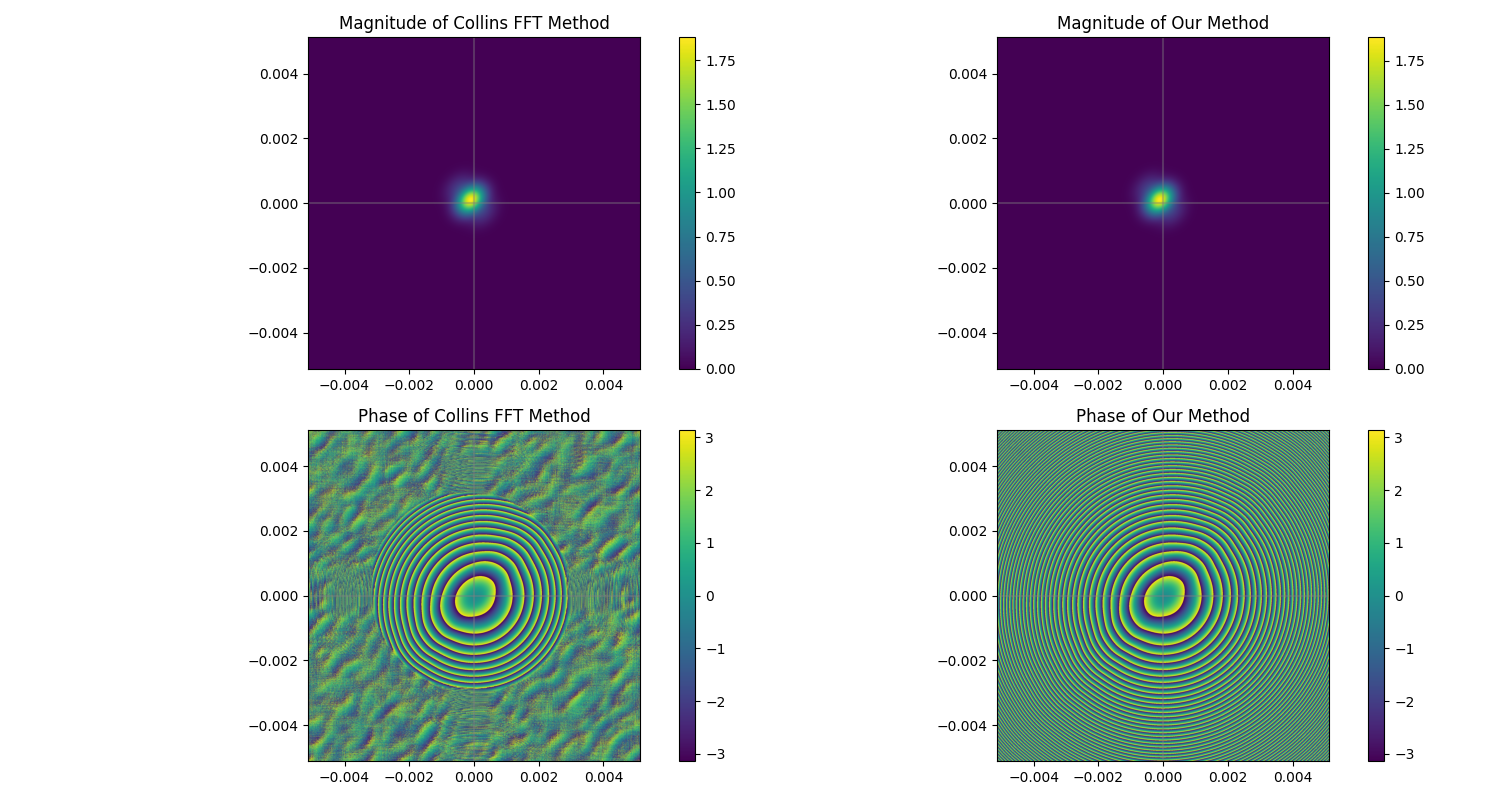

In [96]:
# Create a 2x3 subplot grid for the images
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Top-left: Magnitude of gaussian_FFT
im = axes[0, 0].imshow(np.abs(gaussian_FFT), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[0, 0].set_title('Magnitude of Collins FFT Method')
fig.colorbar(im, ax=axes[0, 0])

# Top-middle: Magnitude of gaussian_analytic
im = axes[0, 1].imshow(np.abs(gaussian_analytic), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[0, 1].set_title('Magnitude of Our Method')
fig.colorbar(im, ax=axes[0, 1])

# Bottom-left: Phase of gaussian_FFT
im = axes[1, 0].imshow(np.angle(gaussian_FFT), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[1, 0].set_title('Phase of Collins FFT Method')
fig.colorbar(im, ax=axes[1, 0])

# Bottom-middle: Phase of gaussian_analytic
im = axes[1, 1].imshow(np.angle(gaussian_analytic), extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
axes[1, 1].set_title('Phase of Our Method')
fig.colorbar(im, ax=axes[1, 1])


# Add center lines on each subplot
for row in axes:
    for ax in row:
        ax.axhline(y=0, color='gray', alpha=0.4)
        ax.axvline(x=0, color='gray', alpha=0.4)

plt.tight_layout()
plt.show()